In [21]:
import pandas as pd
df = pd.read_csv('Subject 1.csv', parse_dates=['EventDateTime'])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11042 entries, 0 to 11041
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   EventDateTime               11042 non-null  datetime64[ns]
 1   DeviceMode                  0 non-null      float64       
 2   BolusType                   593 non-null    object        
 3   Basal                       7419 non-null   float64       
 4   CorrectionDelivered         593 non-null    float64       
 5   TotalBolusInsulinDelivered  593 non-null    float64       
 6   FoodDelivered               593 non-null    float64       
 7   CarbSize                    593 non-null    float64       
 8   CGM                         11042 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 776.5+ KB


In [22]:
df = df.sort_values('EventDateTime')

In [23]:
df['EventDateTime'] = pd.to_datetime(df['EventDateTime'])
df = df.set_index('EventDateTime')

In [24]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['day_night'] = df['hour'].apply(lambda x: 0 if (x < 6 or x >= 20) else 1)


In [25]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)



In [26]:
df['FoodDelivered'].fillna(0, inplace=True)
df['TotalBolusInsulinDelivered'].fillna(0,inplace=True)

/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_7786/2558290490.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FoodDelivered'].fillna(0, inplace=True)
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_7786/2558290490.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [27]:
df = df.drop(columns=['DeviceMode'])

In [28]:
df['BolusType'] = df['BolusType'].fillna('NoBolus')

In [29]:
df = pd.get_dummies(df, columns=['BolusType'], prefix='Bolus')

In [30]:
df['ActiveBolus'] = df['TotalBolusInsulinDelivered'].rolling(window=24, min_periods=1).sum()

In [31]:
df['FoodDelivered'].fillna(0, inplace=True)
df['CarbSize'].fillna(0, inplace=True)
df['TotalBolusInsulinDelivered'].fillna(0, inplace=True)
df['Basal'].fillna(method='ffill', inplace=True)  
df['CorrectionDelivered'].fillna(0, inplace=True) 
df['Basal'].fillna(df['Basal'].mean(), inplace=True)


/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_7786/1495881271.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FoodDelivered'].fillna(0, inplace=True)
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_7786/1495881271.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [32]:
features = [
    'hour_sin', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_night',
    'FoodDelivered', 'CarbSize',
    'TotalBolusInsulinDelivered', 'Basal', 'CorrectionDelivered',
    'ActiveBolus', 'Bolus_Automatic Bolus/Correction', 'Bolus_BLE Standard Bolus/Correction', 'Bolus_Extended 50.00%/0.00',
    'Bolus_Standard', 'Bolus_Standard/Correction', 'Bolus_NoBolus'
]

target = 'CGM'

In [51]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_7786/1144704714.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CGM_lag_5'] = df['CGM'].shift(1).fillna(method='bfill')
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_7786/1144704714.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CGM_lag_10'] = df['CGM'].shift(2).fillna(method='bfill')
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_7786/1144704714.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CGM_lag_15'] = df['CGM'].shift(3).fillna(method='bfill')


Epoch 1/60


/Users/user/anaconda3/envs/my_cozy_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


550/552 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0527

552/552 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0328 - val_loss: 0.0140
Epoch 2/60
550/552 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0141

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 10, 16)         │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_20 (GRU)                    │ (None, 10, 32)         │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_21 (GRU)                    │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,397 (99.21 KB)

 Trainable params: 8,465 (33.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,932 (66.14 KB)

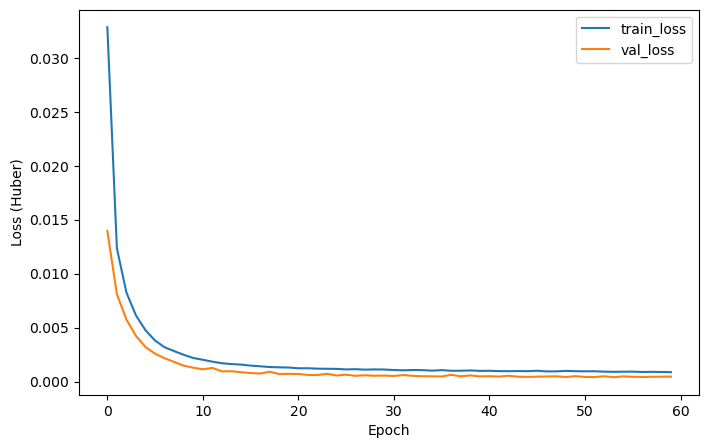

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


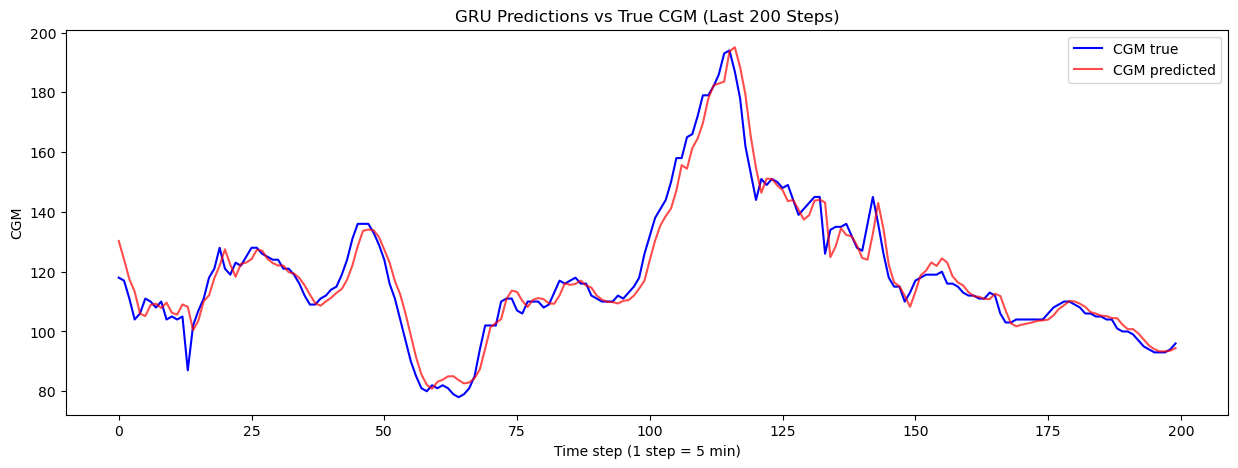

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Conv1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

df['delta_CGM'] = df['CGM'].diff().fillna(0)  
df['CGM_roll_3'] = df['CGM'].rolling(window=3, min_periods=1).mean()  

df['CGM_lag_5'] = df['CGM'].shift(1).fillna(method='bfill')
df['CGM_lag_10'] = df['CGM'].shift(2).fillna(method='bfill')
df['CGM_lag_15'] = df['CGM'].shift(3).fillna(method='bfill')
df['delta_CGM_2'] = df['CGM'].diff(2).fillna(0)

features_with_delta = features + ['delta_CGM', 'CGM_roll_3', 'CGM_lag_5', 'CGM_lag_10', 'CGM_lag_15', 'delta_CGM_2']
target = 'CGM'

scaler_X = MinMaxScaler()
df[features_with_delta] = scaler_X.fit_transform(df[features_with_delta])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(df[target].values.reshape(-1,1))

window_size = 12  
X, y = [], []

for i in range(len(df) - window_size):
    X.append(df[features_with_delta].iloc[i:i+window_size].values)
    y.append(y_scaled[i+window_size]) 

X = np.array(X)
y = np.array(y)

split = int(len(X) * 0.8)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

model = Sequential()
model.add(Conv1D(filters=16, kernel_size=3, activation='relu',
                 input_shape=(X.shape[1], X.shape[2])))

model.add(GRU(32,
              return_sequences=True,
              dropout=0.2,
              kernel_regularizer=l2(0.0005)))

model.add(GRU(16,
              dropout=0.2,
              kernel_regularizer=l2(0.0005)))

model.add(Dense(8, activation='relu'))
model.add(Dense(1))

optimizer = Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer, loss=Huber(delta=0.5))  

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    'best_model.h5', monitor='val_loss', save_best_only=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)

model.summary()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.legend()
plt.show()

y_pred_scaled = model.predict(X_val)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_val)

n_steps = 200
plt.figure(figsize=(15,5))
plt.plot(y_true[-n_steps:], label='CGM true', color='blue')
plt.plot(y_pred[-n_steps:], label='CGM predicted', color='red', alpha=0.7)
plt.xlabel('Time step (1 step = 5 min)')
plt.ylabel('CGM')
plt.title('GRU Predictions vs True CGM (Last 200 Steps)')
plt.legend()
plt.show()


In [64]:
errors = pd.DataFrame({
    'time_step': np.arange(len(y_true)),
    'CGM_true': y_true.flatten(),
    'CGM_pred': y_pred.flatten()
})
errors['abs_error'] = np.abs(errors['CGM_true'] - errors['CGM_pred'])
errors['percent_error'] = errors['abs_error'] / errors['CGM_true'] * 100

top_errors = errors.nlargest(10, 'abs_error')
print(top_errors)


      time_step  CGM_true    CGM_pred  abs_error  percent_error
273         273     214.0  142.584702  71.415298      33.371635
1807       1807     158.0  186.517120  28.517120      18.048810
1716       1716      84.0  111.109398  27.109398      32.273093
1165       1165     279.0  252.268127  26.731873       9.581316
242         242     105.0  131.682648  26.682648      25.412045
1164       1164     261.0  234.634827  26.365173      10.101599
161         161      79.0  104.255531  25.255531      31.969027
9             9     132.0  156.368027  24.368027      18.460626
1170       1170     200.0  223.872665  23.872665      11.936333
227         227     109.0  132.852173  23.852173      21.882727


In [65]:
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 2.88%


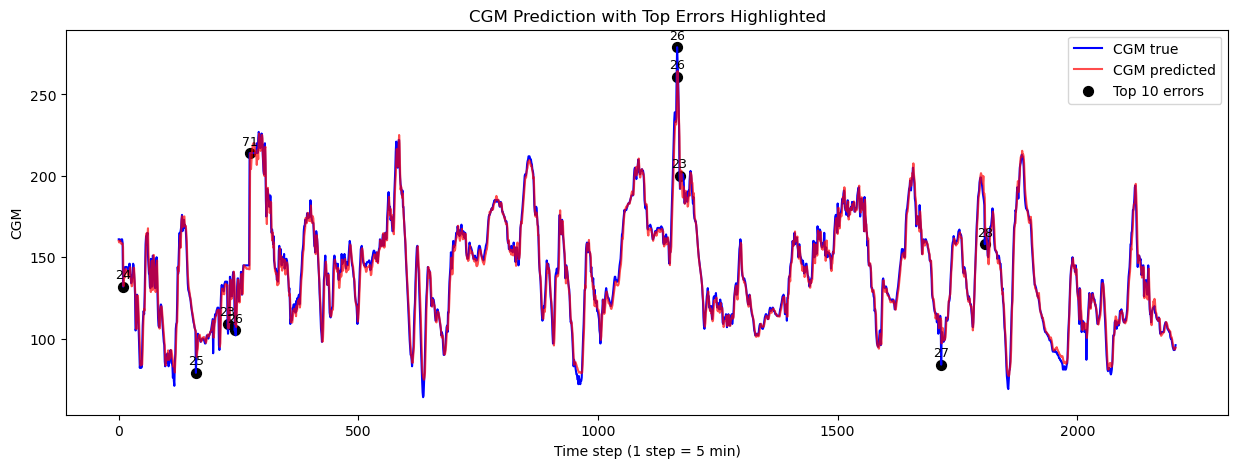

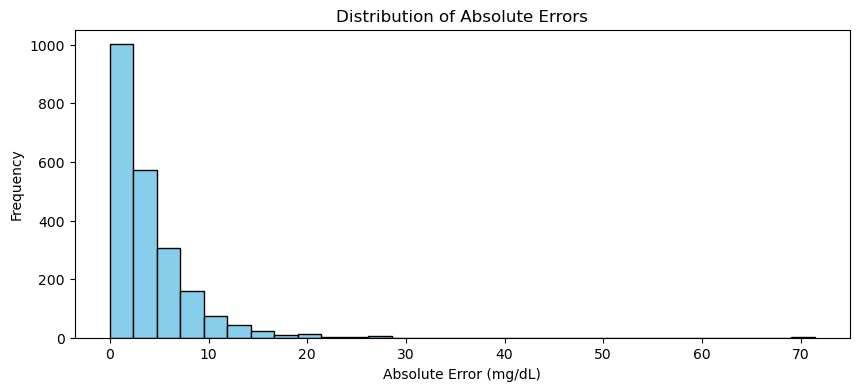

In [66]:
plt.figure(figsize=(15,5))
plt.plot(y_true, label='CGM true', color='blue')
plt.plot(y_pred, label='CGM predicted', color='red', alpha=0.7)
plt.scatter(top_errors['time_step'], top_errors['CGM_true'], color='black', label='Top 10 errors', s=50)

for i, row in top_errors.iterrows():
    plt.text(row['time_step'], row['CGM_true'] + 5, f"{int(row['abs_error'])}", 
             color='black', fontsize=9, ha='center')

plt.xlabel('Time step (1 step = 5 min)')
plt.ylabel('CGM')
plt.title('CGM Prediction with Top Errors Highlighted')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.hist(errors['abs_error'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Absolute Error (mg/dL)')
plt.ylabel('Frequency')
plt.title('Distribution of Absolute Errors')
plt.show()